# EDA de Sentinel-5P sobre Cali

Sentinel-5P es un satélite europeo que da la vuelta al planeta midiendo gases en la atmósfera. Lleva un solo instrumento, el TROPOMI, que mira la luz del sol que rebota en la Tierra y, según cómo esa luz cambia de color, deduce cuánto hay de cada gas.

De ese instrumento salen varios productos. Aquí trabajamos con siete: los tres gases que nos interesan para calidad del aire (dióxido de nitrógeno **NO2**, dióxido de azufre **SO2** y ozono **O3**), dos gases de apoyo (monóxido de carbono **CO** y formaldehído **HCHO**), un índice de aerosoles (**AER_AI**, polvo y humo en el aire) y la fracción de nube (**CLOUD**).

Una idea que conviene tener clara desde ya: el satélite mide la **columna**. Imagina una chimenea de aire que va desde el suelo hasta el espacio sobre cada punto de Cali; el satélite cuenta cuántas moléculas de gas hay en toda esa chimenea. No mide lo que respiramos a ras de suelo. Esa diferencia entre "columna" y "superficie" va a aparecer varias veces y la resolvemos al final.

Este notebook es autocontenido: parte de los archivos crudos (las imágenes del satélite, el Excel de las estaciones de tierra y los archivos de clima) y calcula todo lo que muestra. No depende de ningún resultado precocinado.

## Preparación

Dejamos el entorno listo antes de tocar los datos: herramientas, estilo, rutas y unas cuantas constantes.

### *Importación de dependencias*

In [1]:
import io
import glob
from pathlib import Path
from datetime import date

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import rasterio
import xarray as xr
from scipy import stats

### *Estilo de las gráficas y semilla*

In [2]:
try:
    get_ipython().run_line_magic("matplotlib", "inline")
except Exception:
    pass

sns.set_theme(style="whitegrid", context="notebook")
plt.rcParams["figure.dpi"] = 110
plt.rcParams["axes.titleweight"] = "bold"

SEED = 137
rng = np.random.default_rng(SEED)

### *Ubicación de los datos*

In [3]:
def find_root(marker="data/sentinel5p/l3"):
    p = Path.cwd()
    for _ in range(8):
        if (p / marker).exists():
            return p
        p = p.parent
    raise FileNotFoundError("No encuentro la raíz del proyecto.")


ROOT = find_root()
L3 = ROOT / "data" / "sentinel5p" / "l3"
DAGMA_XLSX = ROOT / "data" / "dagma" / "SVCASC_FT_50-Datos_Monitores_SVCASC_2020-2025.xlsx"
ERA5_DIR = ROOT / "data" / "era5"
print("Raíz del proyecto:", ROOT)

Raíz del proyecto: C:\Users\mitgar14\Desktop\Ingenieria de Datos e IA - UAO\Semestre 7\Analítica\Semana #12 - #17\Proyecto


### *Constantes del dominio*

In [4]:
GASES = ["NO2", "SO2", "O3"]
TODOS = ["NO2", "SO2", "O3", "CO", "HCHO", "AER_AI", "CLOUD"]
COLOR = {"NO2": "#d62728", "SO2": "#ff7f0e", "O3": "#2ca02c",
         "CO": "#9467bd", "HCHO": "#8c564b", "AER_AI": "#1f77b4", "CLOUD": "#7f7f7f"}

# Geometría de la grilla del satélite (todas las imágenes comparten estos números).
LEFT, TOP, PIX = -77.000352, 5.000023, 0.01

# Un punto representativo del centro de Cali y la estación de Univalle (lon, lat).
LON_CALI, LAT_CALI = -76.50, 3.425
LON_UNI, LAT_UNI = -76.53372474, 3.37796681

# Recorte urbano de Cali dentro de la grilla, en filas y columnas.
R0, R1, C0, C1 = 145, 170, 40, 60

# Lo que pesa un mol de NO2, para pasar de columna a masa al final.
M_NO2 = 46.0

# Las nueve estaciones de monitoreo de DAGMA (lon, lat).
ESTACIONES = {
    "Base Aérea": (-76.50653649, 3.45731978),
    "ERA Obrero": (-76.51908184, 3.44759410),
    "Cañaveralejo": (-76.54961789, 3.41545841),
    "Univalle": (-76.53372474, 3.37796681),
    "Pance": (-76.53125401, 3.30449556),
    "Transitoria": (-76.49495633, 3.41717874),
    "Compartir": (-76.46657547, 3.42825808),
    "La Flora": (-76.51805771, 3.48822548),
    "La Ermita": (-76.53097834, 3.45551754),
}

### *Funciones de apoyo*

In [5]:
def fmt(n, dec=0):
    """Número al estilo local: punto para miles, coma para decimales."""
    s = f"{n:,.{dec}f}"
    return s.replace(",", "X").replace(".", ",").replace("X", ".")


def rc(lon, lat):
    """Pasa una coordenada (lon, lat) a la fila y columna de la grilla."""
    return int((TOP - lat) / PIX), int((lon - LEFT) / PIX)


# El satélite mejora su algoritmo cada cierto tiempo y publica una versión nueva. Estas son
# las versiones vigentes durante los cinco años del proyecto, con la fecha en que empezó cada una.
VERSIONES = [
    (date(2019, 11, 13), "01.03.01"),
    (date(2020, 11, 17), "01.04.00"),
    (date(2021, 7, 1),  "02.02.00"),
    (date(2021, 11, 14), "02.03.01"),
    (date(2022, 3, 12), "02.04.00"),
    (date(2022, 7, 25), "02.05.00"),
    (date(2023, 9, 8),  "02.06.00"),
    (date(2024, 1, 16), "02.07.01"),
]


def version_de(fecha):
    """Dada una fecha, devuelve la versión del procesador vigente ese día."""
    d = fecha.date() if hasattr(fecha, "date") else fecha
    ver = VERSIONES[0][1]
    for f_ini, v in VERSIONES:
        if d >= f_ini:
            ver = v
    return ver

## 1. Qué tenemos en la mano

Cada archivo es un día de un producto, guardado como una imagen (un GeoTIFF) en una carpeta con forma de año, mes y día. Sin abrir las imágenes todavía, recorremos las carpetas y armamos la lista de todo lo que hay, sacando la fecha y el producto del nombre de cada archivo.

Archivos en total: 12.784
Fechas distintas:  1.827
Período cubierto:  2020-01-01 a 2024-12-31


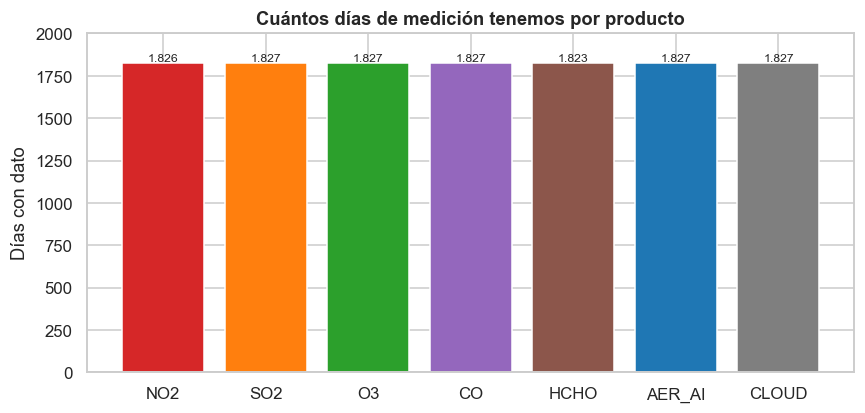

In [6]:
archivos = sorted(glob.glob(str(L3 / "**" / "*.tif"), recursive=True))
filas = []
for p in archivos:
    pp = Path(p)
    y, m, d = pp.parent.parts[-3:]
    filas.append({"date": pd.Timestamp(int(y), int(m), int(d)), "producto": pp.stem, "path": p})
inv = pd.DataFrame(filas)
por_prod = inv["producto"].value_counts().reindex(TODOS)

print(f"Archivos en total: {fmt(len(inv))}")
print(f"Fechas distintas:  {fmt(inv['date'].nunique())}")
print(f"Período cubierto:  {inv['date'].min().date()} a {inv['date'].max().date()}")

fig, ax = plt.subplots(figsize=(9, 4))
ax.bar(TODOS, [por_prod[p] for p in TODOS], color=[COLOR[p] for p in TODOS], edgecolor="white")
for i, p in enumerate(TODOS):
    ax.text(i, por_prod[p] + 10, fmt(por_prod[p]), ha="center", fontsize=8)
ax.set_ylabel("Días con dato")
ax.set_ylim(0, 2000)
ax.set_title("Cuántos días de medición tenemos por producto")
plt.show()

Los siete productos rondan los 1.827 días, que son los cinco años completos de 2020 a 2024. En otras palabras, casi todos los días del período tienen medición de casi todo. Es una base cómoda para trabajar.

## 2. Dónde cae cada píxel

Abrimos una sola imagen para ver en qué coordenadas está y de qué tamaño es cada celda. Como todas las imágenes comparten la misma grilla, con una basta. El sistema es el de longitud y latitud de siempre (EPSG:4326) y cada celda mide 0,01 grados de lado, algo así como un kilómetro. Esto fija el "grano" con el que el satélite ve la ciudad.

In [7]:
with rasterio.open(inv["path"].iloc[0]) as src:
    crs = src.crs
    H, W = src.shape
    b = src.bounds

print("Sistema de coordenadas:", crs)
print(f"Tamaño de celda:        {PIX} x {PIX} grados")
print(f"Grilla completa:        {W} x {H} celdas")
print(f"Esquina suroeste:       lon {fmt(b.left, 3)}, lat {fmt(b.bottom, 3)}")
print(f"Esquina noreste:        lon {fmt(b.right, 3)}, lat {fmt(b.top, 3)}")

Sistema de coordenadas: EPSG:4326
Tamaño de celda:        0.01 x 0.01 grados
Grilla completa:        121 x 201 celdas
Esquina suroeste:       lon -77,000, lat 2,990
Esquina noreste:        lon -75,790, lat 5,000


Un detalle que importa más adelante: una celda de un kilómetro es grande comparada con Cali. La ciudad entera entra en muy pocas celdas, así que el satélite la ve como pocos puntos, no como un mapa fino. Para medir distancias de verdad (en metros) habría que pasar a coordenadas UTM, pero para explorar nos quedamos en grados.

## 3. Qué tan completa es la serie en el tiempo

Una cosa es tener muchos archivos y otra es que estén bien repartidos en el tiempo. Un mapa de calor por mes nos dice de un vistazo si hay épocas sin dato. Cuanto más oscuro, más días medidos ese mes. De paso revisamos si hay huecos largos, es decir tramos de más de tres días seguidos sin ninguna imagen.

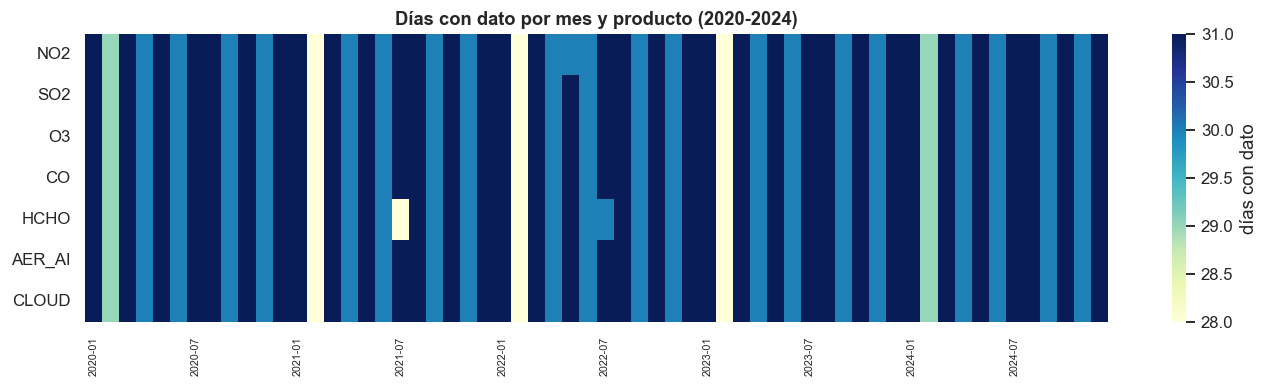

Huecos temporales de más de tres días seguidos: 0


In [8]:
inv["mes"] = inv["date"].dt.to_period("M").astype(str)
piv = inv.pivot_table(index="producto", columns="mes", values="path",
                      aggfunc="count", fill_value=0).reindex(TODOS)

fig, ax = plt.subplots(figsize=(15, 3.4))
sns.heatmap(piv, cmap="YlGnBu", cbar_kws={"label": "días con dato"}, ax=ax)
ax.set_xlabel(""); ax.set_ylabel("")
ax.set_xticks(np.arange(0, piv.shape[1], 6) + 0.5)
ax.set_xticklabels(piv.columns[::6], rotation=90, fontsize=7)
ax.set_title("Días con dato por mes y producto (2020-2024)")
plt.show()

fechas_unicas = pd.Series(sorted(inv["date"].unique()))
n_gaps = int((fechas_unicas.diff().dt.days > 3).sum())
print(f"Huecos temporales de más de tres días seguidos: {n_gaps}")

El mapa es casi uniforme y no hay ningún hueco largo. Esto significa que no tenemos que inventar datos para tapar vacíos: la serie está prácticamente completa los cinco años.

## 4. Una sola pasada por todas las escenas

Hasta aquí solo miramos nombres de archivos y una imagen suelta. Ahora viene el paso pesado: abrir las casi trece mil imágenes, una por una, y sacar de cada una lo que nos va a servir después. De cada escena anotamos el valor justo sobre un punto representativo de Cali, el valor sobre la estación de Univalle (que usaremos al final), un resumen del recorte urbano (promedio, dispersión y cuántos valores distintos tiene) y si la imagen salió "plana", es decir sin ninguna variación, señal de que el control de calidad la dejó vacía. De paso vamos sumando las escenas de NO2 para armar el mapa promedio de la ciudad. Hacerlo todo en una sola pasada evita releer las imágenes una y otra vez.

In [9]:
fila_cali, col_cali = rc(LON_CALI, LAT_CALI)
fila_uni, col_uni = rc(LON_UNI, LAT_UNI)

registros = []
acc = np.zeros((R1 - R0, C1 - C0))
cnt = np.zeros_like(acc)

for r in inv.itertuples():
    with rasterio.open(r.path) as src:
        a = src.read(1).astype(float)
    sub = a[R0:R1, C0:C1]
    registros.append({
        "date": r.date,
        "producto": r.producto,
        "val_cali": a[fila_cali, col_cali],
        "val_uni": a[fila_uni, col_uni],
        "bbox_mean": float(sub.mean()),
        "bbox_nunicos": int(np.unique(sub).size),
        "banda_std": float(a.std()),
        "vmin": float(a.min()),
        "vmax": float(a.max()),
    })
    if r.producto == "NO2" and a.std() > 0:
        m = sub > 0
        acc[m] += sub[m]
        cnt[m] += 1

esc = pd.DataFrame(registros)
no2_map = np.where(cnt > 0, acc / cnt, np.nan)
print(f"Escenas leídas: {fmt(len(esc))}")

Escenas leídas: 12.784


Quedó una tabla con una fila por escena. De aquí en adelante todo sale de esta tabla y del mapa de NO2 que fuimos acumulando, sin volver a tocar el disco salvo para las fuentes de tierra y clima del final.

## 5. El satélite cambia con los años

El instrumento no mide igual toda su vida. Cada cierto tiempo la agencia que lo opera mejora el algoritmo que traduce la luz cruda en concentración, y publica una versión nueva del procesador. Esas mejoras son buenas, pero crean un problema: si comparamos un año con otro sin darnos cuenta de que cambió la versión, podemos confundir una mejora del software con un cambio real del aire. Como las imágenes no traen escrita su versión, la deducimos a partir de la fecha de cada una.

Hay una versión en particular, la 02.06.00, que tuvo un tropiezo conocido: cambió la forma de estimar las nubes y eso desajustó el NO2 durante unos meses. La marcamos en negro para tenerla vigilada.

Versiones del procesador presentes en el NO2:
  01.03.01: 321 días
  01.04.00: 226 días
  02.02.00: 136 días
  02.03.01: 118 días
  02.04.00: 134 días
  02.05.00: 410 días
  02.06.00: 130 días
  02.07.01: 351 días


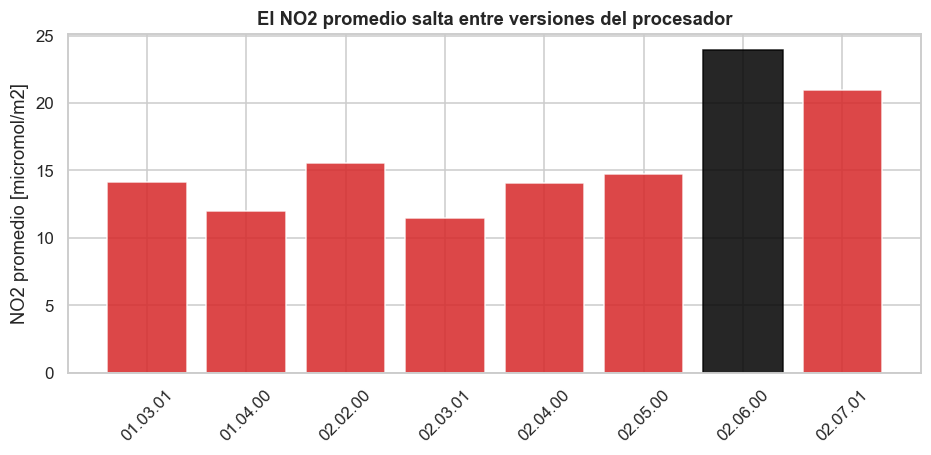

In [10]:
no2 = esc[esc["producto"] == "NO2"].copy()
no2["version"] = no2["date"].apply(version_de)

conteo_ver = no2["version"].value_counts().sort_index()
print("Versiones del procesador presentes en el NO2:")
for v, n in conteo_ver.items():
    print(f"  {v}: {fmt(n)} días")

drift = (no2.groupby("version")["val_cali"].mean() * 1e6).sort_index()

fig, ax = plt.subplots(figsize=(10, 4))
bars = ax.bar(drift.index, drift.values, color="#d62728", edgecolor="white", alpha=0.85)
for b, v in zip(bars, drift.index):
    if v == "02.06.00":
        b.set_color("black")
ax.set_ylabel("NO2 promedio [micromol/m2]")
ax.set_title("El NO2 promedio salta entre versiones del procesador")
ax.tick_params(axis="x", rotation=45)
plt.show()

Las barras no están a la misma altura aunque el aire de fondo de Cali no cambie tanto de un año a otro. Parte de esa diferencia es la versión del procesador, no el aire. La barra negra (la versión con el tropiezo de las nubes) es de las más altas. La lección práctica: cualquier comparación entre años hay que hacerla mirando la versión, no revolviendo todo junto.

Nota sobre las unidades: la columna se mide en mol por metro cuadrado, un número diminuto (del orden de 0,00001). Para que las gráficas sean legibles lo multiplicamos por un millón y lo mostramos en micromol por metro cuadrado. Sigue siendo columna, no superficie.

## 6. Cómo se reparten los valores (y por qué hay negativos)

Al mirar la distribución de cada gas aparece algo que puede asustar: hay valores negativos. Una concentración negativa no existe en el mundo real, pero sí tiene sentido en la medición. El satélite resta un fondo y, cuando hay muy poco gas, el ruido de la medición puede dejar el resultado un pelín por debajo de cero. Ese ruido es información legítima, así que **no lo borramos**: borrarlo sesgaría todo hacia arriba.

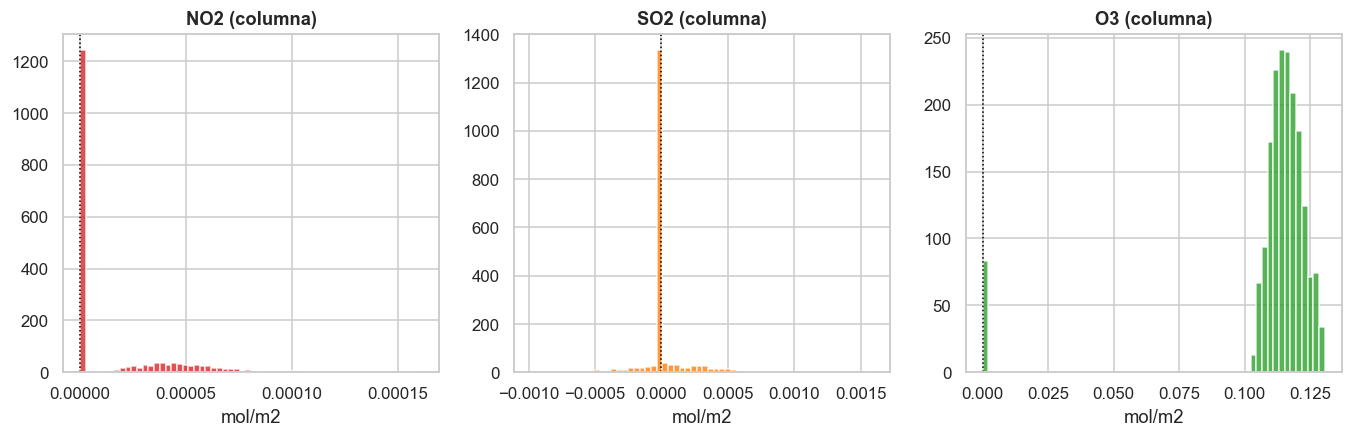

NO2: 0,0% de días con valor negativo (ruido físico, se conserva)
SO2: 11,0% de días con valor negativo (ruido físico, se conserva)
O3: 0,0% de días con valor negativo (ruido físico, se conserva)


In [11]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
for ax, g in zip(axes, GASES):
    v = esc[esc["producto"] == g]["val_cali"].dropna()
    ax.hist(v, bins=60, color=COLOR[g], alpha=0.8, edgecolor="white")
    ax.axvline(0, color="black", lw=1, ls=":")
    ax.set_title(f"{g} (columna)")
    ax.set_xlabel("mol/m2")
plt.show()

for g in GASES:
    v = esc[esc["producto"] == g]["val_cali"].dropna()
    neg_pct = (v < 0).mean() * 100
    print(f"{g}: {fmt(neg_pct, 1)}% de días con valor negativo (ruido físico, se conserva)")

El NO2 y el SO2 muestran esa cola hacia la izquierda esperable. Es normal en una ciudad tropical con concentraciones de fondo bajas. La regla que seguimos es simple: incluir el ruido tal cual y no maquillar la distribución.

## 7. La historia en el tiempo, partida por versión

Ahora vemos la serie completa de cada gas, día a día, con una línea suave de tendencia encima. Las líneas punteadas verticales marcan cada cambio de versión del procesador. Así, si vemos un escalón en la serie justo sobre una línea punteada, sabemos que es sospechoso de venir del software y no del aire.

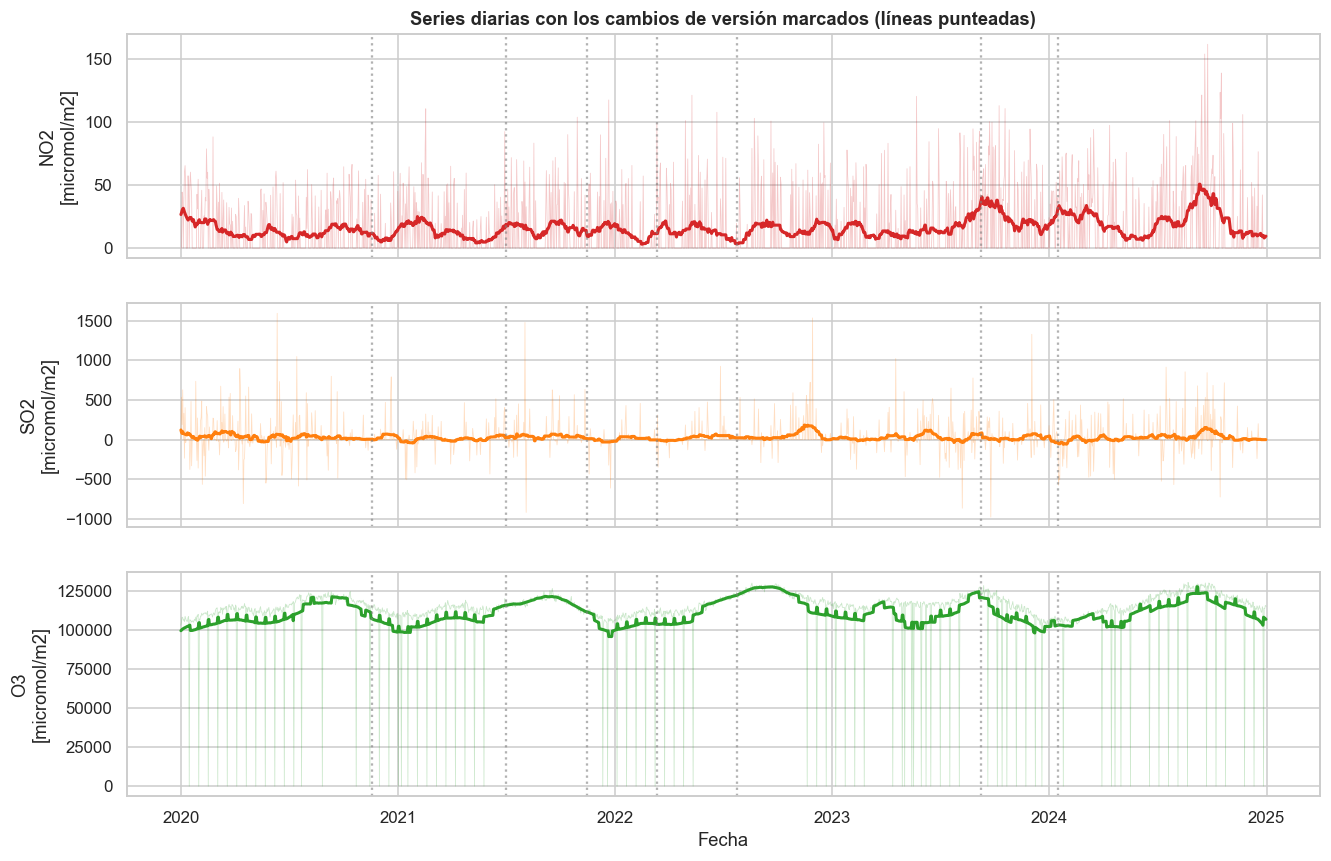

In [12]:
cambios = [pd.Timestamp(f) for f, _ in VERSIONES
           if inv["date"].min() <= pd.Timestamp(f) <= inv["date"].max()]

fig, axes = plt.subplots(3, 1, figsize=(14, 9), sharex=True)
for ax, g in zip(axes, GASES):
    s = esc[esc["producto"] == g].set_index("date").sort_index()["val_cali"] * 1e6
    ax.plot(s.index, s, color=COLOR[g], alpha=0.25, lw=0.5)
    ax.plot(s.index, s.rolling(30, min_periods=5, center=True).mean(), color=COLOR[g], lw=2)
    for c in cambios:
        ax.axvline(c, color="gray", ls=":", alpha=0.6)
    ax.set_ylabel(f"{g}\n[micromol/m2]")
axes[0].set_title("Series diarias con los cambios de versión marcados (líneas punteadas)")
axes[-1].set_xlabel("Fecha")
plt.show()

El NO2 tiene varios escalones que coinciden con cambios de versión. El O3 en cambio se mueve suave y estacional, sin saltos bruscos: es un gas mucho más estable a esta escala.

## 8. El control de calidad ya viene puesto

Estos datos llegan con un control de calidad de fábrica. Antes de que lleguen a nosotros, cada celda pasó un filtro: si la medición de ese día no era confiable (demasiada nube, geometría de observación mala, retrieval dudoso), se descarta en el origen. Por eso no tenemos que volver a filtrar: el trabajo de calidad ya está hecho.

Esto explica algo que de otra forma confunde: cuando veas huecos o ceros en el NO2, **no es que falte el dato**, es que ese día, en esa celda, la medición no pasó el control. La forma de comprobarlo es ver que lo que sí queda cae dentro del rango físico razonable para una ciudad.

In [13]:
pct_constante = (no2["bbox_nunicos"] == 1).mean() * 100
n_degen_no2 = int((no2["banda_std"] == 0).sum())
v_no2 = no2.loc[no2["val_cali"] != 0, "val_cali"].dropna() * 1e6

print(f"Escenas de NO2 sin ninguna variación sobre Cali: {fmt(pct_constante, 1)}%")
print(f"Escenas de NO2 totalmente vacías (todo en cero):  {fmt(n_degen_no2)}")
print(f"NO2 válido sobre Cali, rango habitual (p1 a p99):  "
      f"{fmt(np.percentile(v_no2, 1), 2)} a {fmt(np.percentile(v_no2, 99), 2)} micromol/m2")

Escenas de NO2 sin ninguna variación sobre Cali: 34,2%
Escenas de NO2 totalmente vacías (todo en cero):  141
NO2 válido sobre Cali, rango habitual (p1 a p99):  14,91 a 120,49 micromol/m2


El rango habitual del NO2 cae justo donde se espera para una ciudad de tamaño medio, así que el filtro de origen está haciendo bien su trabajo. Lo otro que salta a la vista es que una parte de las escenas no tiene ninguna variación espacial sobre Cali: toda la ciudad sale con el mismo valor. Eso es porque Cali entra en muy pocas celdas del satélite, como vimos en el punto 2. Lo retomamos en el siguiente bloque.

## 9. El mapa del NO2 sobre la ciudad

En la pasada del punto 4 ya fuimos promediando todas las escenas válidas de NO2 sobre el recorte urbano de Cali. Aquí lo dibujamos para ver dónde se concentra, con las nueve estaciones de DAGMA encima.

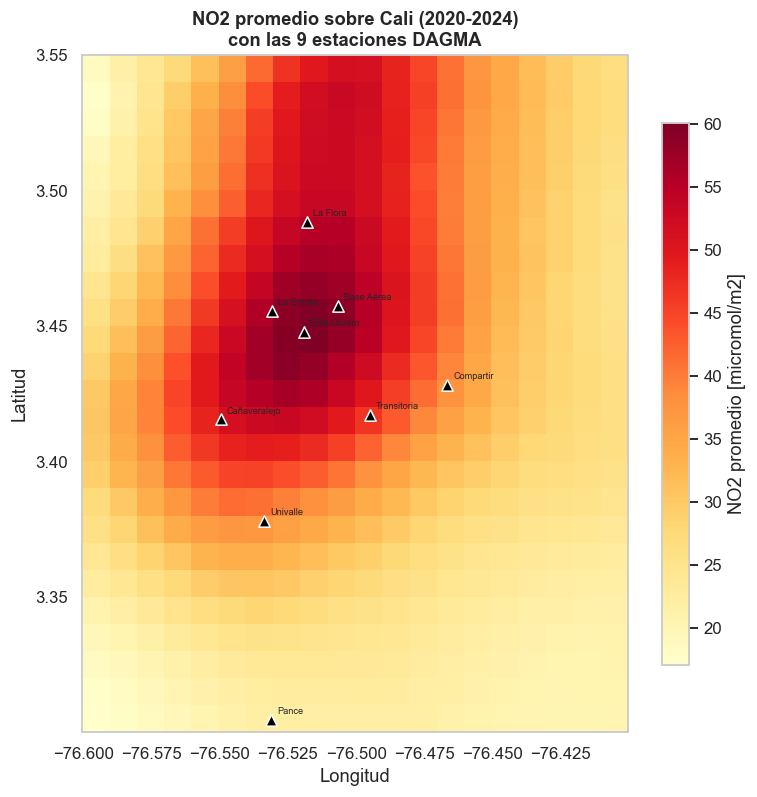

In [14]:
lons = LEFT + (np.arange(C0, C1) + 0.5) * PIX
lats = TOP - (np.arange(R0, R1) + 0.5) * PIX

fig, ax = plt.subplots(figsize=(8, 8))
pc = ax.pcolormesh(lons, lats, no2_map * 1e6, cmap="YlOrRd", shading="auto")
fig.colorbar(pc, ax=ax, label="NO2 promedio [micromol/m2]", shrink=0.8)
for nom, (lo, la) in ESTACIONES.items():
    ax.scatter(lo, la, marker="^", c="black", s=55, edgecolors="white", zorder=5)
    ax.annotate(nom, (lo, la), fontsize=6, xytext=(4, 4), textcoords="offset points")
ax.set_title("NO2 promedio sobre Cali (2020-2024)\ncon las 9 estaciones DAGMA")
ax.set_xlabel("Longitud"); ax.set_ylabel("Latitud")
plt.show()

El NO2 más alto se ve hacia el norte y centro, donde están el tráfico y la actividad industrial; el sur (Pance) sale más limpio. Pero fíjate en lo grueso del pixelado: son pocas celdas. Las nueve estaciones de DAGMA caen en apenas tres o cuatro celdas distintas, o sea que varias estaciones comparten exactamente el mismo valor de satélite. Esta es la razón de fondo por la que más adelante el proyecto necesita afinar el detalle espacial con otras fuentes: el satélite solo, sobre una ciudad, da una imagen muy gruesa.

## 10. Escenas vacías y picos raros

Dos tipos de problema conviven en la serie. El primero son escenas que salieron completamente vacías (todo en cero), que detectamos porque no tienen ninguna variación. El segundo son picos puntuales muy por encima de lo normal, que buscamos con una banda móvil de treinta días: marcamos como pico todo lo que se sale por mucho de lo que vienen siendo los días cercanos.

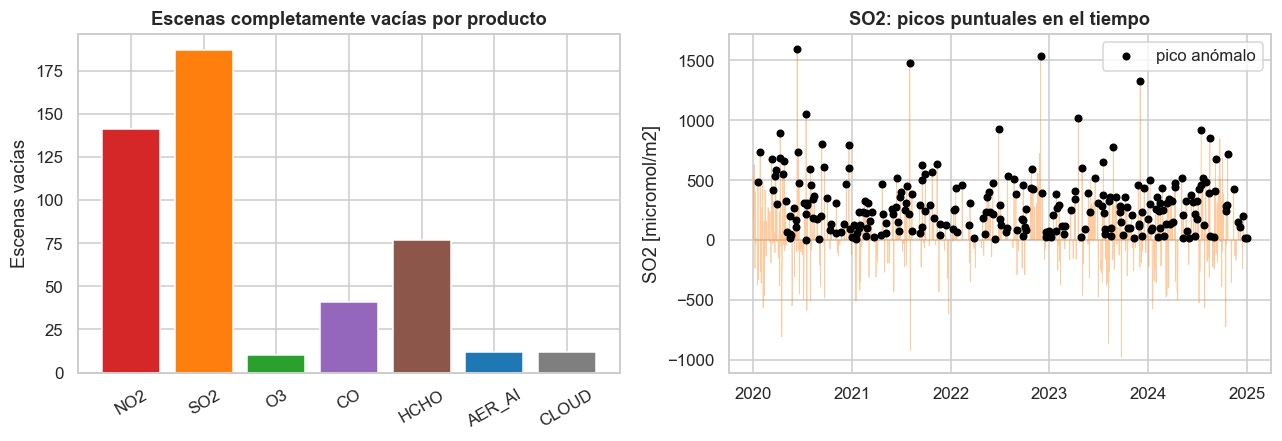

Escenas vacías en total: 480
Picos anómalos de SO2:   250


In [15]:
degen = esc[esc["banda_std"] == 0]
deg_por = degen["producto"].value_counts().reindex(TODOS).fillna(0)

so2 = esc[esc["producto"] == "SO2"].set_index("date").sort_index()["val_cali"]
med = so2.rolling(30, min_periods=5, center=True).median()
q1 = so2.rolling(30, min_periods=5, center=True).quantile(0.25)
q3 = so2.rolling(30, min_periods=5, center=True).quantile(0.75)
iqr = q3 - q1
es_pico = so2 > (med + 3 * iqr)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 4))
ax1.bar(TODOS, [deg_por[p] for p in TODOS], color=[COLOR[p] for p in TODOS], edgecolor="white")
ax1.set_ylabel("Escenas vacías")
ax1.set_title("Escenas completamente vacías por producto")
ax1.tick_params(axis="x", rotation=30)

ax2.plot(so2.index, so2 * 1e6, color=COLOR["SO2"], alpha=0.4, lw=0.5)
ax2.scatter(so2.index[es_pico], so2[es_pico] * 1e6, color="black", s=18, zorder=5, label="pico anómalo")
ax2.set_ylabel("SO2 [micromol/m2]")
ax2.set_title("SO2: picos puntuales en el tiempo")
ax2.legend()
plt.show()

print(f"Escenas vacías en total: {fmt(len(degen))}")
print(f"Picos anómalos de SO2:   {fmt(int(es_pico.sum()))}")

El SO2 es el peor de todos: tiene muchísimas más escenas vacías que el resto. Esto no es mala suerte, es física del instrumento. El SO2 que hay sobre Cali es tan poco que casi siempre queda por debajo de lo que el satélite puede distinguir del ruido, salvo en eventos grandes (una erupción volcánica lejana, una quema fuerte). En la práctica, el SO2 de satélite sobre la ciudad aporta poca señal útil, y conviene tenerlo presente cuando se modele.

## 11. Del satélite al suelo: comparación con DAGMA

Llega el momento de enfrentar el satélite con la realidad de tierra. La estación de Univalle (la única con NO2 utilizable en Cali) mide la concentración a ras de suelo, en microgramos por metro cúbico, que es lo que de verdad respira la gente. El satélite, ya lo dijimos, mide la columna entera. Son dos cosas distintas, y antes de compararlas vale la pena mirar un detalle que lo complica todo: la hora del día.

El Excel de DAGMA viene con tres filas de encabezado y la hora en formato propio, así que al leerlo le indicamos dónde están los nombres y le pedimos que respete el día antes que el mes. De todas las columnas de NO2 nos quedamos con la que tiene datos de verdad, que es la de Univalle.

Columna de NO2 elegida: Univalle


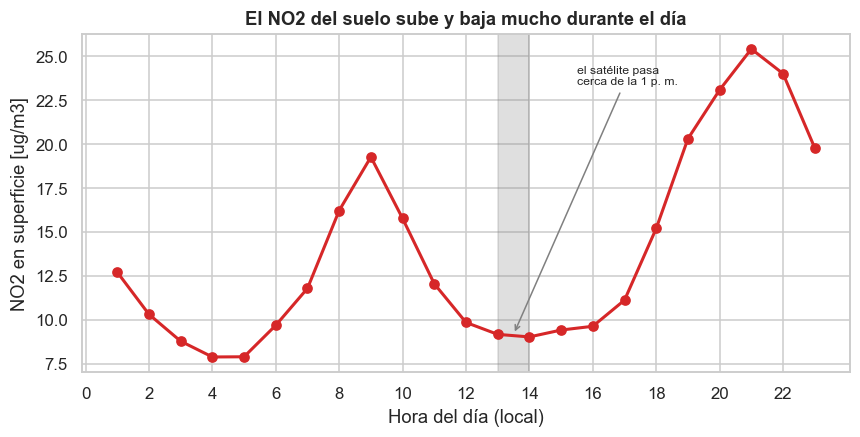

In [16]:
raw = pd.read_excel(DAGMA_XLSX, sheet_name=0, engine="openpyxl", header=[22, 23, 24])
raw.columns = [f"{a}|{b}|{c}" for a, b, c in raw.columns]
raw = raw.rename(columns={raw.columns[0]: "fecha_hora"})
raw["fecha_hora"] = pd.to_datetime(raw["fecha_hora"], errors="coerce", dayfirst=True)
raw = raw.dropna(subset=["fecha_hora"])

cols_no2 = [c for c in raw.columns if "|NO2|" in c.upper()]
col_uni = max(cols_no2, key=lambda c: pd.to_numeric(raw[c], errors="coerce").notna().sum())
print("Columna de NO2 elegida:", col_uni.split("|")[0])

dag = pd.DataFrame({
    "datetime": raw["fecha_hora"],
    "no2_ug_m3": pd.to_numeric(raw[col_uni], errors="coerce"),
}).dropna()
dag = dag[dag["datetime"].dt.year.between(2020, 2024)].copy()
dag["hour"] = dag["datetime"].dt.hour
dag["date"] = dag["datetime"].dt.normalize()
ciclo = dag.groupby("hour")["no2_ug_m3"].mean()

fig, ax = plt.subplots(figsize=(9, 4))
ax.plot(ciclo.index, ciclo.values, "o-", color=COLOR["NO2"], lw=2)
ax.axvspan(13, 14, color="gray", alpha=0.25)
ax.annotate("el satélite pasa\ncerca de la 1 p. m.", xy=(13.5, ciclo.loc[13]),
            xytext=(15.5, ciclo.max() * 0.92), fontsize=8,
            arrowprops=dict(arrowstyle="->", color="gray"))
ax.set_xlabel("Hora del día (local)")
ax.set_ylabel("NO2 en superficie [ug/m3]")
ax.set_title("El NO2 del suelo sube y baja mucho durante el día")
ax.set_xticks(range(0, 24, 2))
plt.show()

El NO2 del suelo tiene dos jorobas: una en la mañana (hora 8 a 9, el tráfico que entra) y otra mayor en la noche (hora 19 a 21, el tráfico que sale más el aire que se queda quieto). Y tiene un valle justo al mediodía. El detalle clave: el satélite pasa cerca de la una de la tarde, o sea en pleno valle. Retrata el NO2 en su momento más bajo del día, mientras la estación vive las jorobas. Solo por eso, esperar que coincidan día a día ya es optimista.

Aun así hacemos la conversión de columna a superficie. La idea es sencilla: si todas las moléculas de la columna estuvieran bien mezcladas dentro de la capa de aire que toca el suelo (la capa de mezcla, de varios cientos de metros de alto), la concentración a ras de suelo es la columna repartida en esa altura. La altura de esa capa la sacamos del modelo de clima ERA5, tomando la hora a la que pasa el satélite.

$$ C_{superficie} = \frac{TVCD}{BLH} \times M \times 10^{6} $$

En palabras:

- **TVCD** es la columna que mide el satélite, las moléculas apiladas en la chimenea de aire (en mol por metro cuadrado).
- **BLH** es la altura de la capa de mezcla en metros, que sacamos de ERA5.
- **M** es lo que pesa un mol de NO2: 46 gramos.
- El **10 elevado a 6** pasa de gramos a microgramos, para quedar en las mismas unidades que mide DAGMA.

Días en que el satélite ve cero NO2 en Univalle (no pasa el filtro): 65,0%
Días con dato útil en ambos lados:                                   440
Correlación día a día (satélite convertido vs DAGMA):                r = -0,122


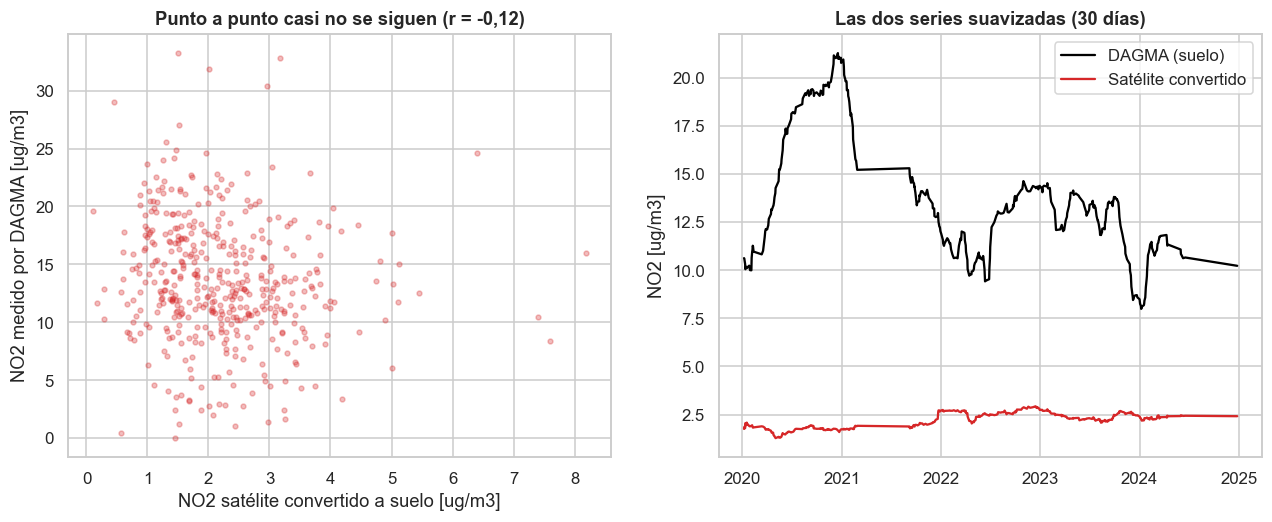

In [17]:
partes = []
for f in sorted(glob.glob(str(ERA5_DIR / "**" / "*blh*.nc"), recursive=True)):
    ds = xr.open_dataset(io.BytesIO(Path(f).read_bytes()), engine="h5netcdf")
    serie_blh = ds["blh"].mean(dim=[d for d in ds["blh"].dims if d in ("latitude", "longitude")]).squeeze()
    partes.append(pd.DataFrame({
        "datetime": pd.to_datetime(serie_blh["valid_time"].values),
        "blh": np.asarray(serie_blh.values).ravel(),
    }))
    ds.close()
era = pd.concat(partes, ignore_index=True)
era["hour"] = era["datetime"].dt.hour
era["date"] = era["datetime"].dt.normalize()
blh_d = era[era["hour"].between(17, 19)].groupby("date")["blh"].mean().reset_index()

s5p_uni = esc[esc["producto"] == "NO2"][["date", "val_uni"]].rename(columns={"val_uni": "tvcd"})
dag_d = dag.groupby("date")["no2_ug_m3"].mean().reset_index()

pct_cero = (s5p_uni["tvcd"] <= 0).mean() * 100
df = s5p_uni.merge(blh_d, on="date").merge(dag_d, on="date")
df = df[df["tvcd"] > 0].dropna()
df["no2_sup"] = (df["tvcd"] / df["blh"]) * M_NO2 * 1e6
r = stats.pearsonr(df["no2_sup"], df["no2_ug_m3"])[0]

print(f"Días en que el satélite ve cero NO2 en Univalle (no pasa el filtro): {fmt(pct_cero, 1)}%")
print(f"Días con dato útil en ambos lados:                                   {fmt(len(df))}")
print(f"Correlación día a día (satélite convertido vs DAGMA):                r = {fmt(r, 3)}")

dd = df.set_index("date").sort_index()
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))
ax1.scatter(df["no2_sup"], df["no2_ug_m3"], s=10, alpha=0.3, c=COLOR["NO2"])
ax1.set_xlabel("NO2 satélite convertido a suelo [ug/m3]")
ax1.set_ylabel("NO2 medido por DAGMA [ug/m3]")
ax1.set_title(f"Punto a punto casi no se siguen (r = {fmt(r, 2)})")
ax2.plot(dd.index, dd["no2_ug_m3"].rolling(30, min_periods=5).mean(),
         color="black", lw=1.5, label="DAGMA (suelo)")
ax2.plot(dd.index, dd["no2_sup"].rolling(30, min_periods=5).mean(),
         color=COLOR["NO2"], lw=1.5, label="Satélite convertido")
ax2.set_ylabel("NO2 [ug/m3]")
ax2.set_title("Las dos series suavizadas (30 días)")
ax2.legend()
plt.show()

El resultado es honesto y vale la pena entenderlo. Primero, en este punto el satélite ve cero la mayoría de los días: el filtro de calidad descarta casi dos tercios de las fechas, porque la señal de NO2 aquí es muy débil. Segundo, en los días que sí mide, no sigue a la estación punto por punto: la correlación es casi nula.

No es un error del análisis, es lo que el dato da, y tiene tres motivos que se suman: el satélite pasa al mediodía, en el valle del ciclo, mientras la estación vive las jorobas; Univalle es de los puntos con menos NO2 de la ciudad, donde al satélite le cuesta separar señal de ruido; y el satélite mide la columna entera mientras la estación mide el suelo, con una relación que cambia según el clima del día.

Lejos de ser un callejón sin salida, esto es justo lo que da sentido al resto del proyecto: pedirle al satélite que adivine el aire del suelo él solo, sobre una sola estación y a la hora menos útil, no alcanza. Por eso la idea es sumarle otras fuentes (vegetación, clima, relieve) para reconstruir el detalle que una sola imagen gruesa no tiene.

## Lo que nos llevamos

El recorrido deja un dato cómodo y unas cuantas cautelas. La cobertura es casi perfecta: cinco años completos, siete productos, sin huecos largos. Pero el satélite mide columna, no superficie, y al bajarla al suelo y enfrentarla día a día con la única estación de NO2 (Univalle) casi no se siguen: allí el satélite ve cero dos de cada tres días y pasa justo a la hora más baja del ciclo. Las actualizaciones del propio satélite meten escalones que hay que tratar por versión. La ciudad entra en pocas celdas, así que el detalle espacial es grueso. Y el SO2 casi no tiene señal útil sobre Cali. Todo esto define cómo hay que tratar al Sentinel-5P en lo que viene: como una pieza valiosa pero que, sola, no llega al detalle que necesitamos, y por eso pide apoyo de otras fuentes.